In [1]:
import pandas as pd
import numpy as np
import os
import joblib

print("Risk scoring environment ready!")

Risk scoring environment ready!


In [2]:
data_path = "../data/CICIDS2017/ml_ready/cicids2017_binary_ml_ready.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (288277, 79)


In [3]:
print("Label distribution:")
print(df["Binary_Label"].value_counts())

print("\nLabel meaning:")
print("0 = BENIGN")
print("1 = ATTACK")

Label distribution:
Binary_Label
0    200000
1     88277
Name: count, dtype: int64

Label meaning:
0 = BENIGN
1 = ATTACK


In [4]:
rf_model_path = "../models/random_forest_baseline.joblib"
isolation_model_path = "../models/isolation_forest_anomaly.joblib"

rf_model = joblib.load(rf_model_path)
isolation_model = joblib.load(isolation_model_path)

print("Random Forest model loaded!")
print("Isolation Forest model loaded!")

Random Forest model loaded!
Isolation Forest model loaded!


In [5]:
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label",
    "Binary_Label"
]

X = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

X = X.replace([np.inf, -np.inf], np.nan)

valid_rows = X.notna().all(axis=1)

X = X.loc[valid_rows].copy()
y = df.loc[valid_rows, "Binary_Label"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (288277, 78)
Target shape: (288277,)


In [6]:
attack_probability = rf_model.predict_proba(X)[:, 1]

print("Attack probabilities generated!")
print("Minimum probability:", attack_probability.min())
print("Maximum probability:", attack_probability.max())
print("Average probability:", attack_probability.mean())

Attack probabilities generated!
Minimum probability: 0.0
Maximum probability: 1.0
Average probability: 0.30635487841287234


In [7]:
isolation_predictions = isolation_model.predict(X)

anomaly_flag = np.where(
    isolation_predictions == -1,
    1,
    0
)

print("Anomaly predictions generated!")

print("\nAnomaly distribution:")
print(pd.Series(anomaly_flag).value_counts())

print("\n0 = Normal")
print("1 = Anomaly")

Anomaly predictions generated!

Anomaly distribution:
0    231005
1     57272
Name: count, dtype: int64

0 = Normal
1 = Anomaly


In [8]:
isolation_score = isolation_model.decision_function(X)

print("Isolation Forest scores generated!")

print("Minimum score:", isolation_score.min())
print("Maximum score:", isolation_score.max())

Isolation Forest scores generated!
Minimum score: -0.2832205658535102
Maximum score: 0.1647085791068994


In [9]:
attack_score = attack_probability * 100

print("Attack score generated!")

print("Minimum:", attack_score.min())
print("Maximum:", attack_score.max())
print("Average:", attack_score.mean())

Attack score generated!
Minimum: 0.0
Maximum: 100.0
Average: 30.635487841287222


In [10]:
risk_score = (
    0.70 * attack_score +
    0.30 * (anomaly_flag * 100)
)

risk_score = np.clip(
    risk_score,
    0,
    100
)

print("Risk scores generated successfully!")

print("Minimum risk score:", risk_score.min())
print("Maximum risk score:", risk_score.max())
print("Average risk score:", risk_score.mean())

Risk scores generated successfully!
Minimum risk score: 0.0
Maximum risk score: 100.0
Average risk score: 27.404942364100954


In [11]:
def get_risk_level(score):
    if score < 25:
        return "LOW"
    elif score < 50:
        return "MEDIUM"
    elif score < 75:
        return "HIGH"
    else:
        return "CRITICAL"


risk_level = [
    get_risk_level(score)
    for score in risk_score
]

print("Risk levels generated!")

Risk levels generated!


In [12]:
results = pd.DataFrame({
    "Actual_Label": y.values,
    "Attack_Probability": attack_probability,
    "Anomaly_Flag": anomaly_flag,
    "Risk_Score": risk_score,
    "Risk_Level": risk_level
})

print("Security results created!")
print(results.head(10))

Security results created!
   Actual_Label  Attack_Probability  Anomaly_Flag  Risk_Score Risk_Level
0             0                0.00             0         0.0        LOW
1             0                0.00             0         0.0        LOW
2             0                0.00             1        30.0     MEDIUM
3             0                0.00             1        30.0     MEDIUM
4             0                0.00             1        30.0     MEDIUM
5             0                0.00             0         0.0        LOW
6             0                0.00             0         0.0        LOW
7             0                0.00             0         0.0        LOW
8             0                0.00             0         0.0        LOW
9             0                0.01             0         0.7        LOW


In [13]:
results["Actual_Label"] = results["Actual_Label"].map({
    0: "BENIGN",
    1: "ATTACK"
})

results["Anomaly_Flag"] = results["Anomaly_Flag"].map({
    0: "NORMAL",
    1: "ANOMALY"
})

print(results.head(10))

  Actual_Label  Attack_Probability Anomaly_Flag  Risk_Score Risk_Level
0       BENIGN                0.00       NORMAL         0.0        LOW
1       BENIGN                0.00       NORMAL         0.0        LOW
2       BENIGN                0.00      ANOMALY        30.0     MEDIUM
3       BENIGN                0.00      ANOMALY        30.0     MEDIUM
4       BENIGN                0.00      ANOMALY        30.0     MEDIUM
5       BENIGN                0.00       NORMAL         0.0        LOW
6       BENIGN                0.00       NORMAL         0.0        LOW
7       BENIGN                0.00       NORMAL         0.0        LOW
8       BENIGN                0.00       NORMAL         0.0        LOW
9       BENIGN                0.01       NORMAL         0.7        LOW


In [14]:
risk_distribution = results["Risk_Level"].value_counts()

print("Risk Level Distribution:")
print(risk_distribution)

Risk Level Distribution:
Risk_Level
LOW         179955
HIGH         50789
CRITICAL     37316
MEDIUM       20217
Name: count, dtype: int64


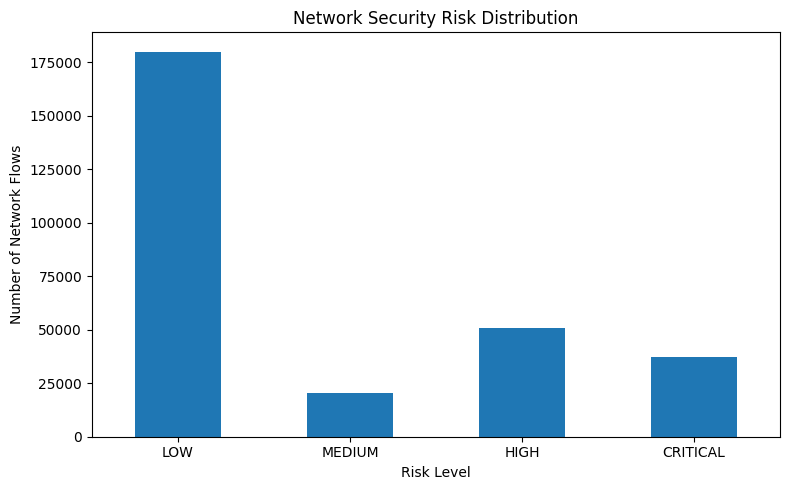

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

risk_distribution.reindex(
    ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
    fill_value=0
).plot(kind="bar")

plt.title("Network Security Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Network Flows")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
risk_attack_table = pd.crosstab(
    results["Risk_Level"],
    results["Actual_Label"]
)

print("Risk Level vs Actual Traffic:")
print(risk_attack_table)

Risk Level vs Actual Traffic:
Actual_Label  ATTACK  BENIGN
Risk_Level                  
CRITICAL       37316       0
HIGH           50740      49
LOW               30  179925
MEDIUM           191   20026


In [18]:
highest_risk = results.sort_values(
    by="Risk_Score",
    ascending=False
).head(20)

print("Top 20 highest-risk network flows:")
print(highest_risk)

Top 20 highest-risk network flows:
       Actual_Label  Attack_Probability Anomaly_Flag  Risk_Score Risk_Level
36034        ATTACK                 1.0      ANOMALY       100.0   CRITICAL
36787        ATTACK                 1.0      ANOMALY       100.0   CRITICAL
36788        ATTACK                 1.0      ANOMALY       100.0   CRITICAL
288220       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
36789        ATTACK                 1.0      ANOMALY       100.0   CRITICAL
288252       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
288244       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
273334       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
288276       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
273335       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
273337       ATTACK                 1.0      ANOMALY       100.0   CRITICAL
273338       ATTACK                 1.0      ANOMALY 

In [19]:
output_dir = "../data/CICIDS2017/ml_ready"

os.makedirs(output_dir, exist_ok=True)

risk_output_path = os.path.join(
    output_dir,
    "cicids2017_risk_scored.csv"
)

results.to_csv(
    risk_output_path,
    index=False
)

print("Risk-scored dataset saved successfully!")
print("Path:", risk_output_path)

Risk-scored dataset saved successfully!
Path: ../data/CICIDS2017/ml_ready\cicids2017_risk_scored.csv


In [20]:
risk_config = {
    "random_forest_weight": 0.70,
    "anomaly_weight": 0.30,
    "risk_score_range": "0-100",
    "risk_levels": {
        "LOW": "0-24",
        "MEDIUM": "25-49",
        "HIGH": "50-74",
        "CRITICAL": "75-100"
    }
}

print("Risk scoring configuration:")
print(risk_config)

Risk scoring configuration:
{'random_forest_weight': 0.7, 'anomaly_weight': 0.3, 'risk_score_range': '0-100', 'risk_levels': {'LOW': '0-24', 'MEDIUM': '25-49', 'HIGH': '50-74', 'CRITICAL': '75-100'}}
